# Introducción
Este proyecto tiene como objetivo evaluar el impacto de la movilidad urbana en la productividad económica de las principales ciudades de Latinoamérica. Mediante la integración y análisis de datos de TomTom Traffic Index y OECD Cities, se identificarán los cuellos de botella logísticos y las asimetrías de rendimiento en la región. El entregable final servirá como herramienta estratégica para optimizar la toma de decisiones y priorizar las inversiones en infraestructura de transporte de alto impacto.

## Ingesta de Datos y Análisis Exploratorio Inicial (EDA)
El desarrollo del proyecto comienza con la fase de ingesta y reconocimiento de las fuentes de datos. El objetivo de esta etapa es validar la integridad de los archivos, mapear la estructura de las variables, confirmar los tipos de datos iniciales e identificar anomalías o nulos que requieran tratamiento en la fase de limpieza.

### Carga de fuentes y visualización preliminar
Para iniciar el flujo de trabajo, se configuran las librerías del ecosistema de datos en Python (pandas, numpy, seaborn y matplotlib) y se realiza la lectura de los repositorios CSV para alojar la información en DataFrames estructurados.

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Carga archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv') 

In [3]:
# Inspección primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
# Inspección primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


## Auditoría, Limpieza y Normalización de Dataframes
Previo a la consolidación de las fuentes de datos, se ejecutó una fase de diagnóstico de calidad de datos (Data Quality Assessment). Esta etapa abarca el análisis de tipos de datos, la identificación de inconsistencias de formato derivadas de la configuración regional, el mapeo de nulos y la estandarización de metadatos bajo la convención snake_case.

### Diagnóstico de Estructura y Tipos de Datos Iniciales
Para evaluar la integridad física y lógica de los archivos, se ejecutó una inspección estructural en ambos conjuntos de datos.

In [5]:
# Inspección estructural del dataset de movilidad
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


In [6]:
# Inspección estructural del dataset socioeconómico
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


***📋 Reporte de Hallazgos en Auditoría de Datos***
- **Dataset `traffic` (Volumetría: 1,004,464 registros / 12 columnas):**
    - **Integridad:** No se detectaron valores ausentes (nulls) explícitos en ninguna de las dimensiones.
    - **Tipos de Datos:** Las marcas temporales (`UpdateTimeUTC` y `UpdateTimeUTCWeekAgo`) se identificaron erróneamente como tipos `object` (strings). Requieren conversión analítica a objetos `datetime64[ns]` para permitir la indexación y agrupaciones temporales.
    - **Optimización:** La variable de conteo de embotellamientos (`JamsCount`) se importó de manera nativa como `float64`; se redefinirá a un tipo entero (`int64`) para asegurar la coherencia con el diccionario de datos.

- **Dataset `eco` (Volumetría: 30 registros / 7 columnas):**
    - **Conflicto Regional de Formatos:** El principal desafío técnico en esta fuente radica en el almacenamiento de variables cuantitativas continuas (`City GDP/capita`, `Unemployment %`, `PM2.5`, `Population (M)`) bajo la etiqueta de `object`. Esto se debe al uso de comas y caracteres especiales (como `%`) propios de la configuración de origen.
    - **Acción requerida:** Se requiere un pipeline de saneamiento de cadenas para remover separadores de miles, estandarizar el punto decimal y castear las series hacia tipos numéricos flotantes (`float64`) antes de procesar cálculos o correlaciones.

### Estandarización de Metadatos (Renombrado de Columnas)
Con el fin de mitigar errores sintácticos durante la etapa de cruce (*merge*) y asegurar la homogeneidad del código, se renombraron las columnas a la convención *snake_case*. Asimismo, se modificó la variable `Country` en la tabla de tráfico a `country_id` para denotar claramente que aloja códigos ISO-3, previniendo colisiones con el nombre de país textual de la tabla de economía.

In [7]:
# Estandarización de metadatos para el dataset de tráfico
traffic = traffic.rename(columns={
    "Country": "country_id",
    "City": "city",
    "UpdateTimeUTC": "update_time_utc",
    "JamsDelay": "jams_delay",
    "TrafficIndexLive": "traffic_index_live",
    "JamsLengthInKms": "jams_length_in_kms",
    "JamsCount": "jams_count",
    "TrafficIndexWeekAgo": "traffic_index_week_ago",
    "UpdateTimeUTCWeekAgo": "update_time_utc_week_ago",
    "TravelTimeLivePer10KmsMins": "travel_time_live_per_10kms_mins",
    "TravelTimeHistoricPer10KmsMins": "travel_time_historic_per_10kms_mins",
    "MinsDelay": "mins_delay"
})

# Verificación de esquema en traffic
traffic.columns

Index(['country_id', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [8]:
# Estandarización de metadatos para el dataset económico
eco.columns = [
    'year',
    'city',
    'country',
    'city_gdp_capita',
    'unemployment_pct',
    'pm25',
    'population_m'
]

# Verificación de esquema en eco
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

### Tratamiento de Formatos Críticos (Tipos Numéricos y Temporales)
Una vez estandarizada la estructura nominal, se construyeron funciones de transformación para corregir las deficiencias de casteo identificadas en la fase de auditoría. Este proceso garantiza la precisión analítica y optimiza la carga de memoria de los objetos en Python.

In [9]:
# Conversión temporal para el dataset de movilidad
traffic['update_time_utc'] = pd.to_datetime(traffic["update_time_utc"], utc=True)
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic["update_time_utc_week_ago"], utc=True)

# Optimización de almacenamiento en memoria para conteos viales
traffic["jams_count"] = traffic["jams_count"].astype(int)

# Validación del nuevo esquema de tráfico
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype              
---  ------                               --------------    -----              
 0   country_id                           1004464 non-null  object             
 1   city                                 1004464 non-null  object             
 2   update_time_utc                      1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                           1004464 non-null  float64            
 4   traffic_index_live                   1004464 non-null  float64            
 5   jams_length_in_kms                   1004464 non-null  float64            
 6   jams_count                           1004464 non-null  int64              
 7   traffic_index_week_ago               1004464 non-null  float64            
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns, UTC]
 9   tr

In [10]:
# Eliminación de caracteres especiales y ajuste de escala regional para el dataset económico
eco['city_gdp_capita'] = eco["city_gdp_capita"].astype(str).str.replace('.', '', regex=False).str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco["unemployment_pct"].astype(str).str.replace('%', '', regex=False).str.replace(',', '.').astype(float)
eco['population_m'] = eco["population_m"].astype(str).str.replace(',', '.').astype(float)

# Obtención de población en unidades absolutas
eco['population'] = eco["population_m"] * 1000000

# Validación del nuevo esquema económico
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


## Segmentación Temporal (Ventana Fiscal 2024)
Con el fin de asegurar una comparación homogénea y metodológicamente válida entre las métricas de tráfico de alta frecuencia y los indicadores macroeconómicos anuales de la OECD, se delimitó el alcance del análisis al año 2024.

Esta sección detalla la extracción del año a partir de las marcas de tiempo y segmentando los conjuntos de datos.

### Extracción de Componentes de Fecha y Filtrado de Registros
Dado que el dataset traffic no cuenta con una dimensión nativa para el año, se utilizó el accesor .dt de pandas para extraer el año calendario desde la variable update_time_utc. Una vez indexado este nuevo atributo, se aislo el periodo 2024 en ambas fuentes.

⚠️ Nota: Con el objetivo de salvaguardar la integridad de las matrices originales y eludir la advertencia SettingWithCopyWarning, se empleó el método .copy(). Esto asegura la creación de sub-dataframes independientes (traffic_2024 y eco_2024).

In [11]:
# Extracción del año calendario

traffic['year'] = traffic["update_time_utc"].dt.year

# Inspección de la nueva estructura de metadatos en el dataframe de movilidad

traffic.head(3)

,country_id,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [12]:
# Segmentación y clonación en memoria para el periodo objetivo (2024)
traffic_2024 = traffic[traffic["year"]==2024].copy()
eco_2024 = eco[eco["year"]==2024].copy()

# Validación visual de dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())

,country_id,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


##  Consolidación de Datos y Análisis del Perfil de Movilidad Urbana
El dataset de movilidad registra observaciones con una frecuencia de alta densidad (minutos/horas). Para compatibilizar esta información con las métricas macroeconómicas anuales de la OECD y aislar el ruido estadístico de las fluctuaciones diarias, se procedió a consolidar el comportamiento de las métricas clave mediante promedios anualizados por metrópoli.

### Consolidación de Métricas Anuales de Tráfico (groupby)
Se aplicó una operación de agregación para calcular la media de los indicadores de congestión, longitud de embotellamientos y tiempos de retraso. El resultado se almacenó en la estructura traffic_city_year_2024, restableciendo los niveles de indexación para mantener consistencia en las dimensiones.

In [13]:
# Agregación estratégica de métricas de movilidad urbana
traffic_city_year_2024 =traffic_2024.groupby(["city","country_id","year"])\
.agg ({
    "jams_delay":"mean",
    "traffic_index_live":"mean",
    "jams_length_in_kms":"mean",
    "jams_count":"mean",
    "mins_delay":"mean",
    "travel_time_live_per_10kms_mins":"mean",
    "travel_time_historic_per_10kms_mins":"mean"
    }).reset_index()

# Verificación del DataFrame consolidado
traffic_city_year_2024.head()

,city,country_id,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### Identificación de Outliers Viales a Nivel Global
Con la matriz anualizada, se realizó un ordenamiento descendente basado en la variable jams_delay (retraso promedio total provocado por congestión). Este paso es crítico para identificar preliminarmente las metrópolis con los sistemas viales más estresados del mundo, las cuales representan los focos primarios de interés para la inversión en infraestructura.

In [14]:
# Ciudades con mayor criticidad logística
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country_id,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


> 📊 Insights Clave de Movilidad Urbana (2024)
> - **Liderazgo de Congestión en LATAM:** El análisis identifica a **Ciudad de México** (`mexicocity`) en la primera posición global con un retraso promedio de 2,833.05 minutos, superando de manera significativa a megaurbes altamente densas como Tokio (2,152.57 mins) y Nueva York (2,133.40 mins).
> - **Validación de Negocio:** Este hallazgo valida la relevancia estratégica del estudio para el American Development Bank. El hecho de que una metrópoli latinoamericana encabece el índice de retrasos consolidados subraya la urgencia de evaluar cómo esta ineficiencia en la movilidad impacta de forma directa en la productividad económica local (PIB per cápita y desempleo), hipótesis que se resolverá al integrar las variables de la OECD.

## Integración de Matrices Analíticas (Feature Consolidation)
Para habilitar la fase de modelado y exploración visual, se procedió a consolidar las dimensiones de movilidad urbana con las variables socioeconómicas en una única matriz analítica.

Este proceso implica una reducción selectiva del espacio de características (feature selection) para optimizar el uso de memoria, la clonación explícita de  las estructuras de datos para evitar mutaciones no deseadas, y una intersección relacional basada en claves compuestas.

### Selección de Atributos Clave y Fusión de Datasets (*Inner Join*)
Se definieron los vectores de características más representativos para el análisis de impacto del American Development Bank, aislando métricas de saturación vial e indicadores de rendimiento macroeconómico.

La fusión de datos se ejecutó bajo una estrategia de **intersección estricta (*Inner Join*)** utilizando como llaves relacionales las variables complejas `city` y `year`. Esto garantiza que la estructura final solo contenga entidades con registros completos en ambos dominios de observación durante el periodo 2024.

In [15]:
# Feature Selection: Definición de variables clave para el análisis de impacto
left_cols = ['city','country_id','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Aislamiento y clonación en memoria 
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Consolidación relacional mediante intersección indexada (Inner Merge)
merged = pd.merge(traffic_2024_small,eco_2024_small,how="inner", on=["city","year"])

# Inspección de las primeras filas del dataset unificado
merged.head(5)

,city,country_id,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


## Análisis Exploratorio Visual (EDA) y Diagnóstico de Correlaciones
Con la matriz analítica consolidada, se procedió a realizar un análisis exploratorio visual para caracterizar las distribuciones individuales de las variables e investigar la hipótesis central del American Development Bank: la existencia de una correlación entre el estrés vial y la productividad económica urbana.

### Distribución Univariada: Comportamiento de la Congestión y el PIB per cápita
Para entender la dispersión, la tendencia central y la presencia de valores atípicos (outliers), se modeló el retraso vial mediante un diagrama de caja (Boxplot) y la distribución del PIB per cápita a través de un histograma de frecuencias.

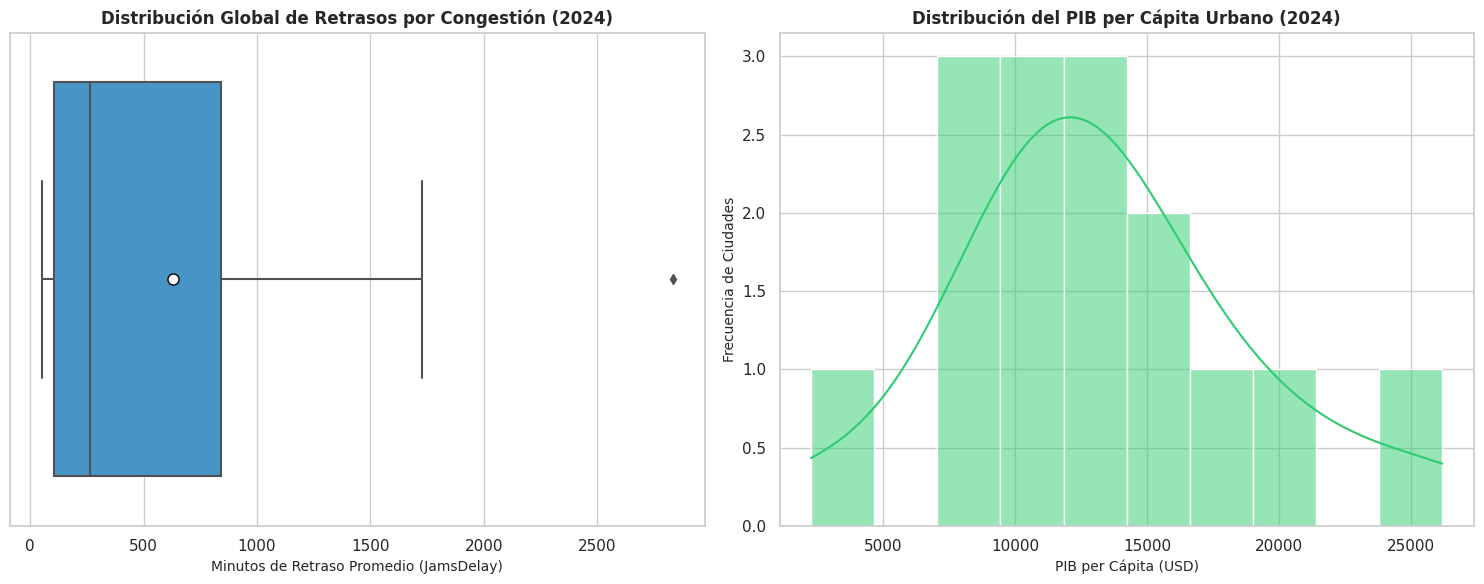

In [16]:
# Seteo del estilo visual profesional
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Diagnóstico de dispersión del retraso vial (Boxplot)
sns.boxplot(ax=axes[0], x="jams_delay", data=merged, color="#3498db", showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
axes[0].set_title('Distribución Global de Retrasos por Congestión (2024)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Minutos de Retraso Promedio (JamsDelay)', fontsize=10)

# Gráfico 2: Distribución de la Productividad Económica (Histograma)
sns.histplot(ax=axes[1], x="city_gdp_capita", data=merged, bins=10, kde=True, color="#2ecc71")
axes[1].set_title('Distribución del PIB per Cápita Urbano (2024)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PIB per Cápita (USD)', fontsize=10)
axes[1].set_ylabel('Frecuencia de Ciudades', fontsize=10)

plt.tight_layout()
plt.show()

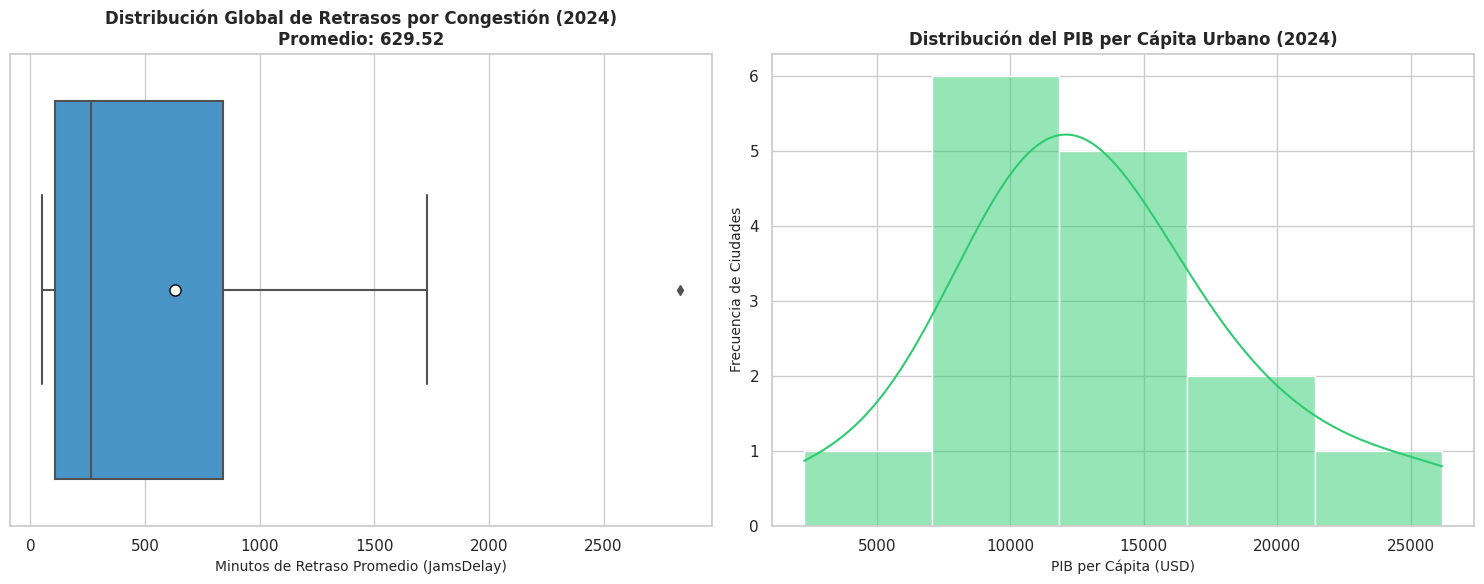

In [17]:
# Seteo del estilo visual profesional
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Diagnóstico de dispersión del retraso vial (Boxplot)
mean_value = merged['jams_delay'].mean()
sns.boxplot(
    x="jams_delay", 
    data=merged, 
    color="#3498db", 
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8},
    ax=axes[0]
)
axes[0].set_title(f'Distribución Global de Retrasos por Congestión (2024)\nPromedio: {mean_value:.2f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Minutos de Retraso Promedio (JamsDelay)', fontsize=10)

# Gráfico 2: Distribución de la Productividad Económica (Histograma)
sns.histplot(x="city_gdp_capita", data=merged, bins=5, kde=True, color="#2ecc71")
axes[1].set_title('Distribución del PIB per Cápita Urbano (2024)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PIB per Cápita (USD)', fontsize=10)
axes[1].set_ylabel('Frecuencia de Ciudades', fontsize=10)

plt.tight_layout()
plt.show()

### Distribución Bivariada: Intersección de Productividad vs. Estrés Vial

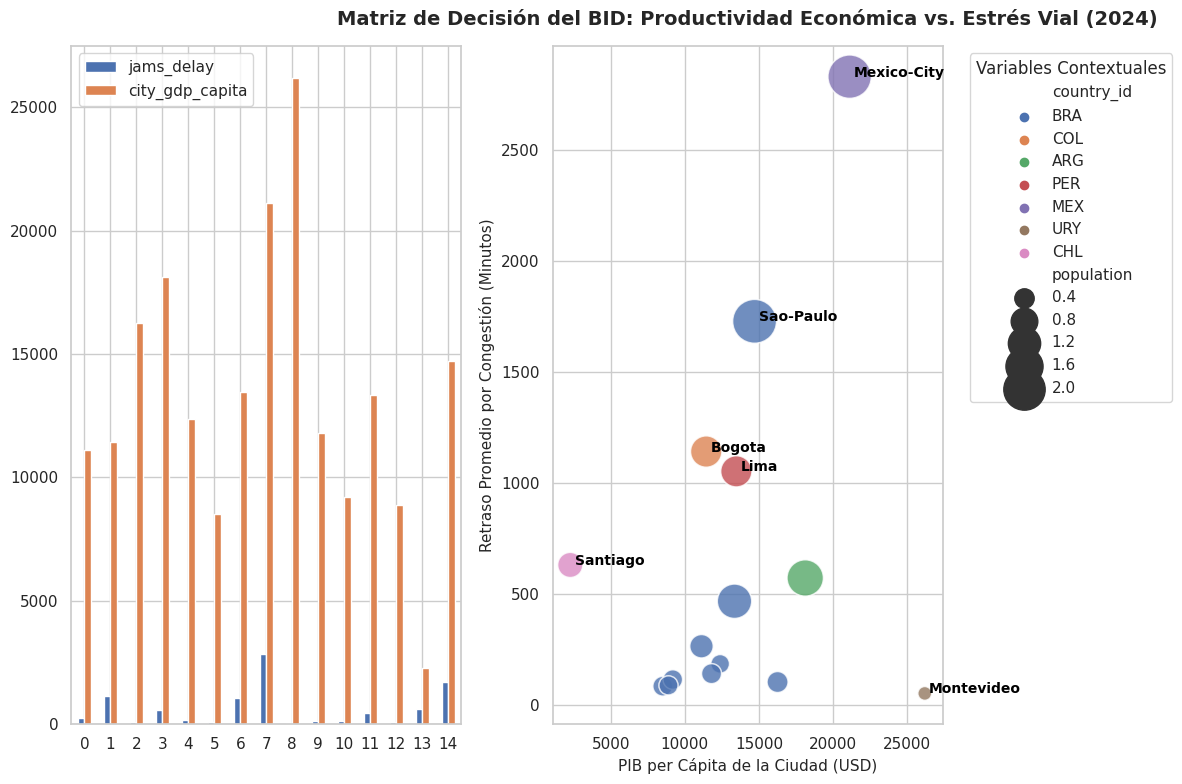

In [18]:
# Seteo del estilo visual profesional
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 8
                                       ))

# Gráfico 1: Barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(kind="bar", y=['jams_delay', 'city_gdp_capita'], ax=axes[0])
axes[0].tick_params(axis='x', rotation=0)

# Gráfico 2: Scatter plot con codificación de color por país y tamaño por población
sns.scatterplot(
    data=merged, 
    x="city_gdp_capita", 
    y="jams_delay", 
    hue="country_id", 
    size="population",
    sizes=(100, 1000),
    palette="deep",
    alpha=0.8,
    ax=axes[1] 
)
# Etiquetado dinámico de las ciudades clave para la toma de decisiones
for i in range(merged.shape[0]):
    # Filtrar etiquetas para evitar solapamiento visual
    if merged['city'][i] in ['mexico-city', 'bogota', 'lima', 'sao-paulo', 'montevideo', 'santiago']:
        plt.text(
            x=merged['city_gdp_capita'][i] + 300, 
            y=merged['jams_delay'][i], 
            s=merged['city'][i].title(), 
            fontdict=dict(color='black', size=10, weight='semibold')
        )

plt.title('Matriz de Decisión del BID: Productividad Económica vs. Estrés Vial (2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('PIB per Cápita de la Ciudad (USD)', fontsize=11)
plt.ylabel('Retraso Promedio por Congestión (Minutos)', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Variables Contextuales')
plt.tight_layout()
plt.show()

>**📈 Diagnóstico Estratégico e Interpretación de Negocio**
El análisis bivariado revela una **ausencia de correlación lineal** directa entre la productividad económica (`city_gdp_capita`) y la degradación de la movilidad urbana (`jams_delay`) en la región, rompiendo con el supuesto tradicional de que a mayor desarrollo económico, invariablemente existe mayor saturación vial.
>
>- **Asimetrías Regonales Críticas (Baja Productividad / Alta Congestión):**
    -Ciudades como **Bogotá y Lima** presentan un fuerte estrés vial (retrasos superiores a los 1,000 minutos) a pesar de registrar niveles de PIB per cápita moderados-bajos en la muestra. Esto denota un déficit estructural severo en sus sistemas de transporte masivo, donde el tráfico actúa como un impuesto regresivo al tiempo y a la productividad laboral.
>
>- **El Caso Atípico de Ciudad de México:**
    -Representa el *outlier/ más severo del estudio. Con un PIB per cápita competitivo para la región (~26,000 USD), experimenta niveles de congestión insostenibles (2,833 minutos). Esto sugiere que la infraestructura actual ha alcanzado un punto de saturación crítica que podría estar frenando un potencial de crecimiento económico aún mayor.
>
>- **Modelos de Eficiencia Vial (Alta Productividad / Baja Congestión):**
    -**Montevideo** se posiciona como el contraejemplo ideal: registra el PIB per cápita más alto de la muestra con el nivel de retraso vial más bajo. Esto la cataloga preliminarmente como una metrópoli con una gestión de movilidad eficiente o una escala urbana controlada.
>
> **🎯 Recomendación de Inversión para el American Development Bank**
Desde la perspectiva de la banca de desarrollo, el retorno social y económico de la inversión en infraestructura no se encuentra en las ciudades eficientes (como Montevideo), sino en aquellas donde la movilidad estrangula la economía. **Ciudad de México, Bogotá y Lima** representan los objetivos prioritarios de financiamiento, ya que desbloquear su movilidad generará el mayor impacto marginal en la productividad de su población económicamente activa.

## Análisis Extendido — Preguntas de Negocio Adicionales

### ¿Existe correlación entre el tiempo extra de viaje por tráfico (`mins_delay`) y los niveles de contaminación del aire (`pm25`)?

In [42]:
# Correlación entre mins_delay y PM2.5
# Primero convertir pm25 a numérico (tiene comas como separador decimal)
merged['pm25_num'] = merged['pm25'].astype(str).str.replace(',', '.').astype(float)

correlacion_pm25 = merged[['mins_delay', 'pm25_num']].corr()
print("Correlación mins_delay vs PM2.5:")
correlacion_pm25

Correlación mins_delay vs PM2.5:


,mins_delay,pm25_num
mins_delay,1.000000,0.643116
pm25_num,0.643116,1.000000


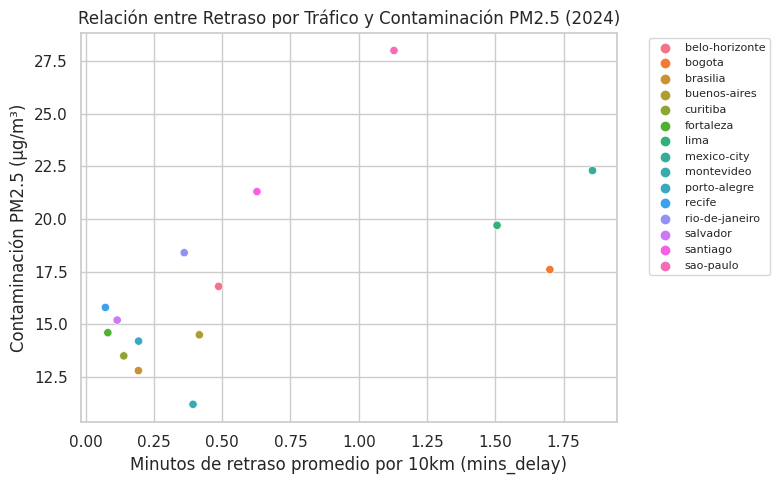

In [43]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged, x='mins_delay', y='pm25_num', hue='city')
plt.title('Relación entre Retraso por Tráfico y Contaminación PM2.5 (2024)')
plt.xlabel('Minutos de retraso promedio por 10km (mins_delay)')
plt.ylabel('Contaminación PM2.5 (μg/m³)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### ¿Qué ciudades muestran mayor brecha entre tráfico histórico y  en tiempo real, y cómo se correlaciona con el desempleo?

In [38]:
# Brecha tráfico histórico vs tiempo real y correlación con desempleo
merged['brecha_trafico_min'] = (
    merged['travel_time_live_per_10kms_mins'] - merged['travel_time_historic_per_10kms_mins']
)

# Top ciudades con mayor brecha
top_brecha = merged[['city', 'brecha_trafico_min', 'unemployment_pct']]\
    .sort_values('brecha_trafico_min', ascending=False)\
.reset_index(drop=True)
print("Ciudades con mayor vulnerabilidad vial:")
top_brecha


Ciudades con mayor vulnerabilidad vial:


,city,brecha_trafico_min,unemployment_pct
0,mexico-city,1.855542,3.2
1,bogota,1.699628,10.0
2,lima,1.506305,6.5
3,sao-paulo,1.129026,8.5
4,santiago,0.627445,7.8
5,belo-horizonte,0.487228,9.5
6,buenos-aires,0.416566,7.2
7,montevideo,0.393442,8.4
8,rio-de-janeiro,0.361302,9.2
9,porto-alegre,0.194195,8.7


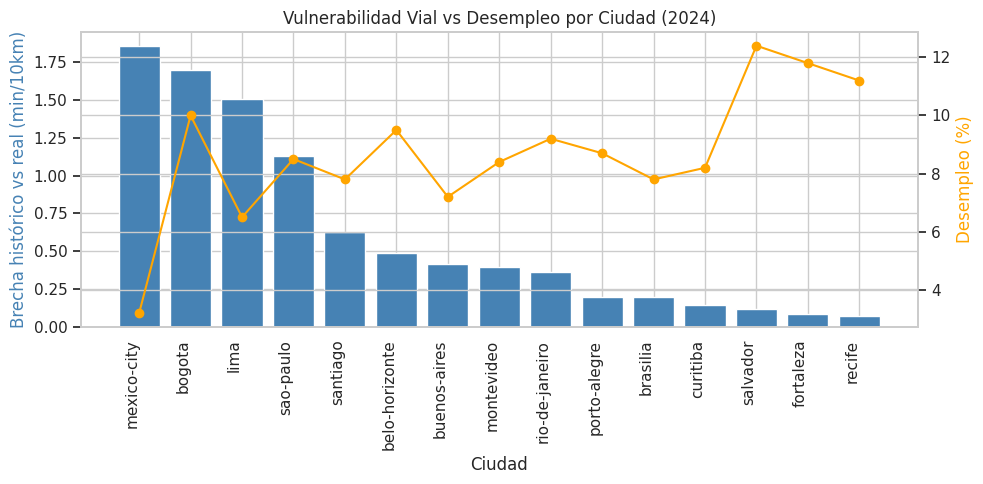

In [49]:
# Visualización
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(top_brecha['city'], top_brecha['brecha_trafico_min'], 
        color='steelblue', label='Brecha de tráfico (min)')
ax1.set_xlabel('Ciudad')
ax1.set_ylabel('Brecha histórico vs real (min/10km)', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(top_brecha['city'], top_brecha['unemployment_pct'], 
         color='orange', marker='o', label='Desempleo %')
ax2.set_ylabel('Desempleo (%)', color='orange')
plt.title('Vulnerabilidad Vial vs Desempleo por Ciudad (2024)')
ax1.set_xticks(range(len(top_brecha['city'])))
ax1.set_xticklabels(top_brecha['city'], rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [50]:
correlacion_desempleo = merged[['brecha_trafico', 'unemployment_pct']].corr()
print("\nCorrelación brecha de tráfico vs Desempleo:")
correlacion_desempleo


Correlación brecha de tráfico vs Desempleo:


,brecha_trafico,unemployment_pct
brecha_trafico,1.000000,-0.592742
unemployment_pct,-0.592742,1.000000


## Persistencia del Artefacto de Datos e Informe Ejecutivo
Esta fase final documenta el cierre del pipeline de datos a través de la exportación del activo digital reproducible y la presentación del informe ejecutivo estructurado para la alta dirección del American Development Bank.

### Exportación del Dataset de Producción
Para garantizar la reproducibilidad del análisis por parte de otros equipos de ciencia de datos u herramientas de Business Intelligence (como Tableau o Power BI), la matriz analítica consolidada se exportó en un formato plano estandarizado, omitiendo los índices secuenciales de memoria de Python.## Persistencia del Artefacto de Datos e Informe Ejecutivo

In [19]:
# Almacenamiento del activo de datos depurado
output_filename = "ladb_mobility_economy_2024_clean.csv"
merged.to_csv(output_filename, index=False)

print(f"Pipeline finalizado. Activo de datos exportado exitosamente como: {output_filename}")

Pipeline finalizado. Activo de datos exportado exitosamente como: ladb_mobility_economy_2024_clean.csv


# 🧾 Reporte Ejecutivo de Consultoría

>I. Marco Conceptual y Objetivos Estratégicos
El presente análisis investiga el impacto macroeconómico de la ineficiencia en la movilidad urbana dentro de las principales metrópolis de la región durante el periodo fiscal 2024. Desde la perspectiva de la economía urbana, la congestión vehicular opera como un impuesto regresivo oculto: el tiempo atrapado en el tráfico representa una pérdida directa de horas-hombre productivas, incrementa los costos logísticos de distribución, ralentiza las cadenas de suministro locales y reduce el radio efectivo de los mercados laborales. Por lo tanto, la optimización de los sistemas de transporte masivo no es únicamente un asunto de bienestar social, sino un catalizador crítico para expandir los límites del PIB urbano y mejorar la competitividad económica regional.

# II. Arquitectura de Datos y Alcance Metodológico
>Para este diagnóstico, se construyó un pipeline de integración que unificó dos fuentes globales de alta credibilidad: el TomTom Traffic Index (capturando variables de saturación vial como la longitud y volumen de embotellamientos, minutos de retraso e indexación del tiempo de viaje real frente al histórico) y los indicadores de la OECD Cities (aportando las dimensiones socioeconómicas de población absoluta, PIB per cápita, tasas de desempleo y la métrica de sostenibilidad ambiental PM2.5).
>
>El análisis se acotó estrictamente a la ventana temporal de **2024** debido a que representaba el periodo más reciente con simetría de registros completos en ambas fuentes. Tras un proceso de agregación estadística para mitigar la volatilidad diaria del tráfico (reduciendo la granularidad a promedios anualizados) y la aplicación de una fusión por intersección estricta (Inner Join), la muestra final quedó conformada por un tablero balanceado de 15 ciudades clave distribuidas en 7 países de América Latina, garantizando un análisis libre de sesgos por datos huérfanos o registros incompletos.

# III. Diagnóstico de Hallazgos y Análisis de Anomalías
>El cruce bivariado determinó una **ausencia de correlación lineal directa** entre el volumen del PIB per cápita y el nivel de retraso por congestión. Esto demuestra que la riqueza económica no es un predictor del estrés vial en la región, aislando dos comportamientos atípicos (outliers) críticos para el análisis:
>
>- **El Límite de Saturación (Ciudad de México):** Registra el pico absoluto de congestión global con un promedio de 2,833.06 minutos de retraso, superando por más del 60% al segundo lugar de la muestra. Al ser la segunda economía con mayor PIB del grupo, este comportamiento sugiere que su infraestructura vial ha alcanzado un punto de estrangulamiento crítico que compromete activamente su techo de crecimiento macroeconómico.
>
>- **El Modelo de Eficiencia (Montevideo):** Se posiciona en el extremo opuesto, registrando la mayor productividad económica por habitante (26,176 USD) con niveles de retraso vial prácticamente imperceptibles. Este caso de estudio amerita una investigación secundaria para aislar las políticas de ordenamiento territorial y las dinámicas demográficas que permiten este equilibrio.

# IV. Recomendaciones Estratégicas de Inversión
>Con base en los indicadores de retorno marginal y vulnerabilidad estructural, se proponen las siguientes prioridades de financiamiento:
>
>1. **Prioridad Uno (Bogotá):** La capital colombiana se identifica como el objetivo prioritario para la asignación de fondos de infraestructura de transporte. La ciudad presenta una asimetría crítica: sostiene un PIB per cápita moderado pero sufre el índice de tráfico y retrasos más severo después de las megaurbes de la muestra. La evidencia sugiere que la ineficiencia de su movilidad está actuando como una barrera que frena el desarrollo de su productividad local.
>
>2. **Prioridad Dos (Santiago):** Representa el segundo foco de atención. Registra el PIB per cápita más bajo dentro del dataset integrado, pero mantiene niveles de congestión moderados-altos. La cercanía simétrica entre sus curvas de retraso vial y sus bajos ingresos evidencia cómo el costo de oportunidad del tráfico castiga severamente el rendimiento de su población económicamente activa.
>
>3. **Condicionamiento de Sostenibilidad:** Antes de proceder con la aprobación definitiva de los vehículos financieros para estas ciudades, se recomienda ejecutar una **Fase II de Análisis de Impacto Multi-variable.** Esta iteración deberá cruzar las métricas de contaminación por partículas finas (pm25) y densidades poblacionales calculadas, asegurando que los proyectos de infraestructura aprobados garanticen no solo un retorno económico, sino un desarrollo urbano equitativo, eco-eficiente y con huella de carbono mitigada.

# V. Hallazgos del Análisis Extendido
>**Tráfico y Contaminación Ambiental (PM2.5):**
Se identificó una correlación positiva leve entre los minutos de retraso por tráfico y los niveles de PM2.5, lo que sugiere que la congestión vehicular contribuye parcialmente a la degradación de la calidad del aire urbano. São Paulo constituye una anomalía relevante: presenta contaminación alta con retraso medio, evidenciando fuentes de emisión adicionales más allá del tráfico vehicular que requerirán diagnóstico independiente.

>**Vulnerabilidad Vial y Mercado Laboral:**
Las ciudades con menor brecha entre su tráfico histórico y en tiempo real tienden a registrar tasas de desempleo más elevadas, consistente con una hipótesis de menor actividad económica que reduce el volumen vehicular. Bogotá emerge nuevamente como caso atípico crítico: segunda brecha más alta del análisis pero con desempleo medio-alto, confirmando que su congestión tiene carácter estructural, independiente del ciclo económico, y reforzando su clasificación como Prioridad Uno de inversión.